# Regression Exercise

In this notebook, we learn how to use scikit-learn to implement simple linear regression, multiple linear regression, and polynomial regression. We download a dataset related to fuel consumption and carbon dioxide emission of cars. Then, we split our data into training and test sets, create a model using the training set, evaluate the model using the test set, and finally use the model to predict unknown values.

# In the Report, compare and discuss the performance of the different regression models based on the obtained results.



# 1. Simple Linear Regression

### Importing Needed packages

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

## Understanding the Data

### `FuelConsumption.csv`
We have downloaded a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64)

- `MODELYEAR` e.g. 2014
- `MAKE` e.g. Acura
- `MODEL` e.g. ILX
- `VEHICLE CLASS` e.g. SUV
- `ENGINE SIZE` e.g. 4.7
- `CYLINDERS` e.g. 6
- `TRANSMISSION` e.g. A6
- `FUEL CONSUMPTION in CITY (L/100 km)` e.g. 9.9
- `FUEL CONSUMPTION in HWY (L/100 km)` e.g. 8.9
- `FUEL CONSUMPTION COMB (L/100 km)` e.g. 9.2
- `CO2 EMISSIONS (g/km)` e.g. 182 --> low --> 0

## Reading the data 

In [45]:
df = pd.read_csv("../data/FuelConsumptionCo2.csv")

# take a look at the dataset
df.head()



,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


### Data Exploration
\end{bmatrix}\longrightarrow \begin{bmatrix}
1 & v\_1 & v\_1^2\\
1 & v\_2 & v\_2^2\\
# summarize the data
1 & v_n & v_n^2

Let's select some features to explore more.

In [46]:
correlation_matrix = df.corr(numeric_only=True)


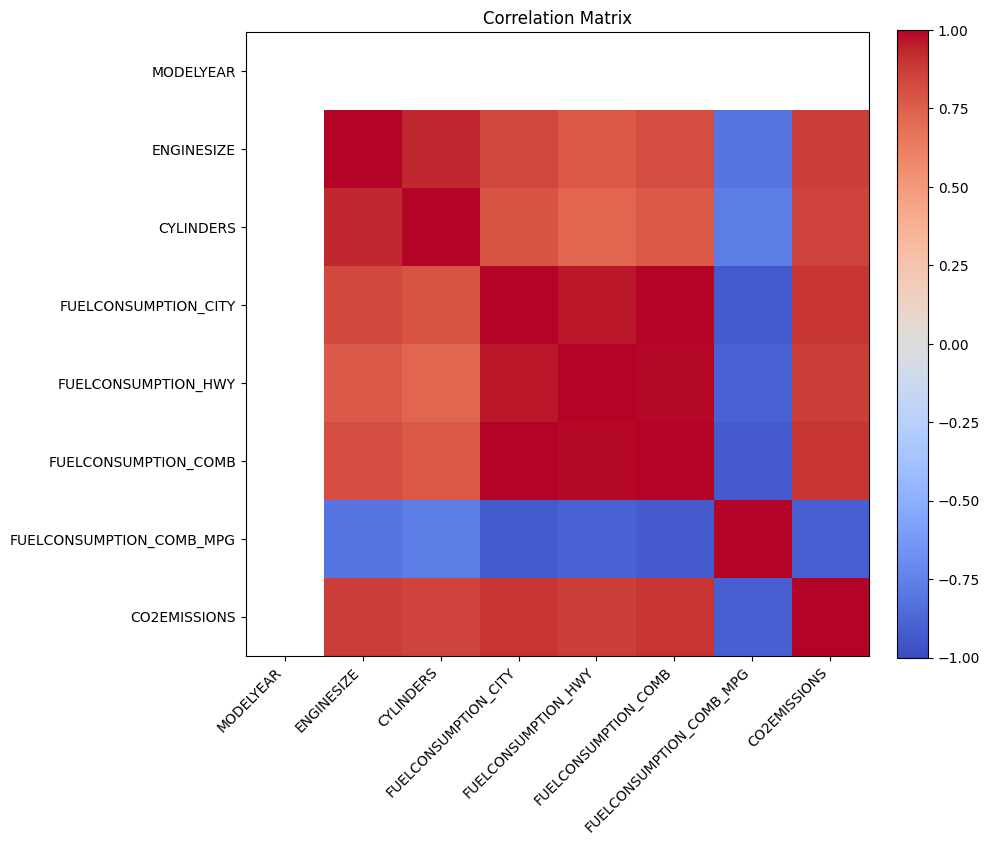

In [47]:
# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(10, 10))

# Draw the heatmap using matplotlib so the notebook does not depend on seaborn
heatmap = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.index)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(correlation_matrix.index)
fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)

ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [48]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']] 
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


We can plot each of these features:

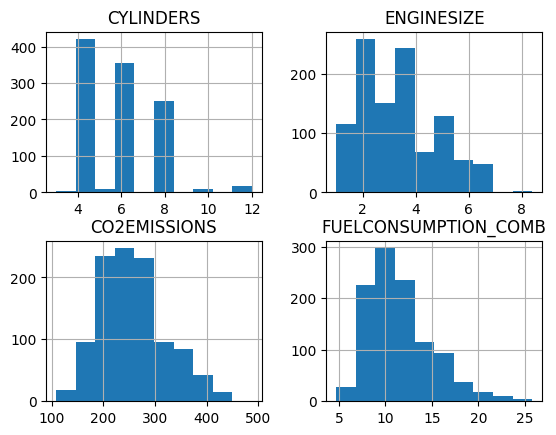

In [49]:
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
viz.hist()
plt.show()

Now, let's plot each of these features vs. the emission to see how linear the relation is:

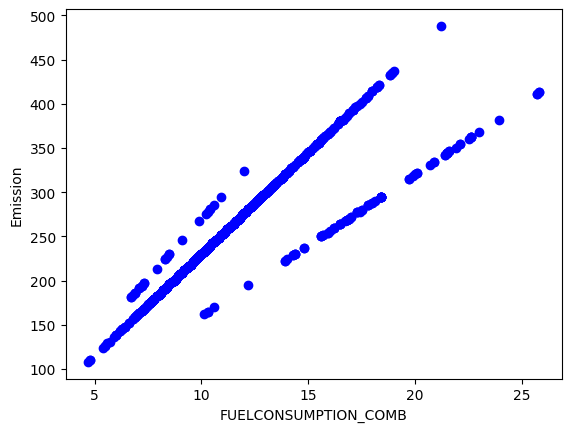

In [50]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

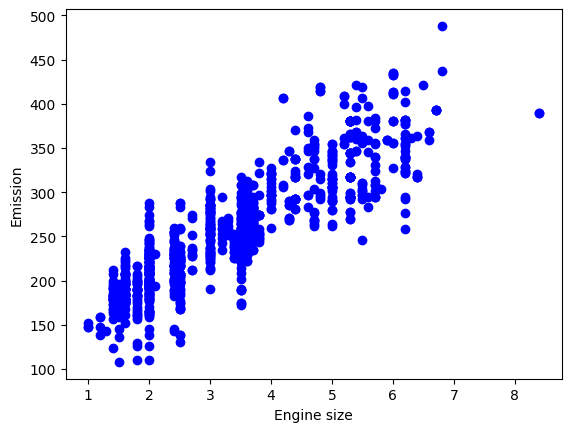

In [51]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

## Practice

Plot __CYLINDERS__ vs. the emission to see how linear the relation is:

In [52]:
# write your code here





#### Creating train and test dataset
Train/Test Split involves splitting the dataset into training and testing sets respectively, which are mutually exclusive. After which, you train with the training set and test with the testing set. 
This will provide a more accurate evaluation on out-of-sample accuracy because the testing dataset is not part of the dataset that have been used to train the data. It is more realistic for real world problems.

This means that we know the outcome of each data point in this dataset, making it great to test with! And since this data has not been used to train the model, the model has no knowledge of the outcome of these data points. So, in essence, it is truly an out-of-sample testing.



In [53]:
# Note: this is another way of splitting the data 
# instead of using " sklearn.model_selection --> train_test_split that used in the Tutoril example
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

### Simple Regression Model
Linear regression fits a linear model with coefficients B = (B1, ..., Bn) to minimize the residual sum of squares between the independent x in the dataset and the dependent y by the linear approximation.

#### Train Data Distribution

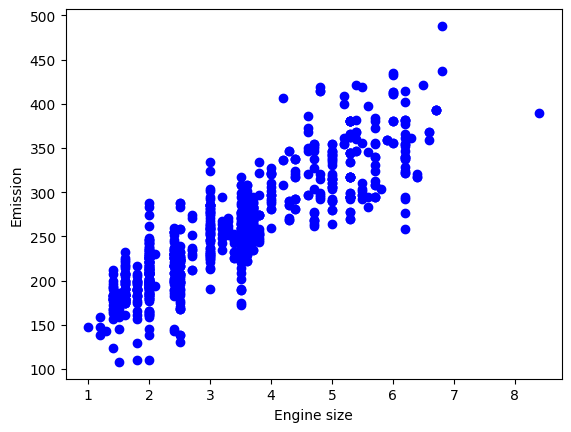

In [54]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

#### Modeling
Using sklearn package to model data.

In [55]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (train_x, train_y)
# The coefficients
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [[39.03164043]]
Intercept:  [125.52687658]


As mentioned before, __Coefficient__ and __Intercept__ in the simple linear regression, are the parameters of the fit line. 
Given that it is a simple linear regression, with only 2 parameters, and knowing that the parameters are the intercept and slope of the line, sklearn can estimate them directly from our data. 
Notice that all of the data must be available to traverse and calculate the parameters.


#### Plot Outputs

We can plot the fit line over the data:

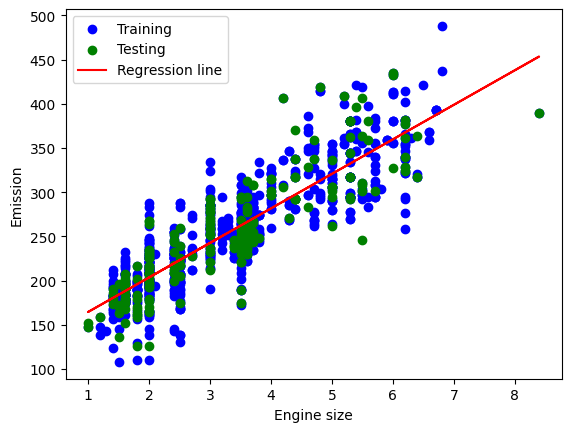

In [56]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.scatter(test.ENGINESIZE, test.CO2EMISSIONS,  color='green')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.legend(['Training','Testing','Regression line'])

There are different model evaluation metrics; let's use MSE here to calculate the accuracy of our model based on the test set:

In [57]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = regr.predict(test_x)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_ , test_y) )

Mean absolute error: 25.60
Residual sum of squares (MSE): 1073.72
R2-score: 0.66


# <center>2-Multiple Linear Regression</center>



In [58]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244
5,3.5,6,11.9,7.7,10.0,230
6,3.5,6,11.8,8.1,10.1,232
7,3.7,6,12.8,9.0,11.1,255
8,3.7,6,13.4,9.5,11.6,267


#### Creating train and test dataset

Train/Test Split involves splitting the dataset into training and testing sets respectively, which are mutually exclusive. After which, you train with the training set and test with the testing set.
This will provide a more accurate evaluation on out-of-sample accuracy because the testing dataset is not part of the dataset that have been used to train the model. Therefore, it gives us a better understanding of how well our model generalizes on new data.

We know the outcome of each data point in the testing dataset, making it great to test with! Since this data has not been used to train the model, the model has no knowledge of the outcome of these data points. So, in essence, it is truly an out-of-sample testing.

Let's split our dataset into train and test sets. Around 80% of the entire dataset will be used for training and 20% for testing. We create a mask to select random rows using the  **np.random.rand()** function:


In [59]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

In reality, there are multiple variables that impact the co2emission. When more than one independent variable is present, the process is called multiple linear regression. An example of multiple linear regression is predicting co2emission using the features FUELCONSUMPTION_COMB, EngineSize and Cylinders of cars. The good thing here is that multiple linear regression model is the extension of the simple linear regression model.


In [60]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
x_train = np.asanyarray(train[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]) # select only three features
y_train = np.asanyarray(train[['CO2EMISSIONS']])

x_test = np.asanyarray(test[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']])
y_test = np.asanyarray(test[['CO2EMISSIONS']])
regr.fit (x_train, y_train)
# The coefficients
print ('Coefficients: ', regr.coef_)

Coefficients:  [[ 9.54912032  7.98291235 10.0297472 ]]


In [61]:
y_pred= regr.predict(test[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']])


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Print the error metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")

Mean Absolute Error (MAE): 16.352644398906403
Mean Squared Error (MSE): 502.26824000829066
R-squared (R²): 0.8641256878866044


/home/mzmzeeee/coding/EC-AI-Python/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


# Practice
Try to use a multiple linear regression with the same dataset, but this time use FUELCONSUMPTION_CITY and FUELCONSUMPTION_HWY instead of FUELCONSUMPTION_COMB. Does it result in better accuracy? 

In [62]:
# Add your code here

# 3. Polynomial Regression

Sometimes the trend of the data is not really linear and looks curvy. In that case, we can use polynomial regression. Many different regressions exist that can fit different dataset shapes, such as quadratic or cubic.

In essence, polynomial regression models the relationship between the independent variable x and the dependent variable y as an nth-degree polynomial in x. For this exercise, think of the 2-degree case as:

- y = b + theta_1 * x + theta_2 * x^2

When we only have x values, such as engine size, we can create a few additional features: 1, x, and x^2.

The PolynomialFeatures() function in the scikit-learn library creates a new feature set from the original feature set. It generates all polynomial combinations of the features up to the specified degree. For example, if the original feature set has only one feature, ENGINESIZE, and we select degree 2, then it generates 3 features: degree 0, degree 1, and degree 2.

In [63]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])


poly = PolynomialFeatures(degree=2)
train_x_poly = poly.fit_transform(train_x)
train_x_poly

array([[ 1.  ,  2.  ,  4.  ],
       [ 1.  ,  2.4 ,  5.76],
       [ 1.  ,  1.5 ,  2.25],
       ...,
       [ 1.  ,  3.2 , 10.24],
       [ 1.  ,  3.2 , 10.24],
       [ 1.  ,  3.2 , 10.24]], shape=(846, 3))

**fit_transform** takes our x values and outputs a list of our data raised from power 0 to power 2, since we set the degree of our polynomial to 2.

The equation and sample example are shown below.

The input vector:

v_1
v_2
...
v_n

maps to the transformed feature matrix:

1  v_1  v_1^2
1  v_2  v_2^2
...
1  v_n  v_n^2

For the sample values:

2.0
2.4
1.5
...

becomes:

1  2.0  4.0
1  2.4  5.76
1  1.5  2.25
...

It looks like feature sets for multiple linear regression analysis, right? Yes, it does. Indeed, polynomial regression is a special case of linear regression, with the main idea being how you select your features. Just consider replacing x with x_1, x_1^2 with x_2, and so on. Then the 2nd-degree equation would turn into y = b + theta_1 * x_1 + theta_2 * x_2.

Now we can deal with it as a linear regression problem. Therefore, this polynomial regression is considered a special case of traditional multiple linear regression. So, you can use the same mechanism as linear regression to solve such problems.

So we can use the LinearRegression() function to solve it:

In [64]:
# Train
clf = linear_model.LinearRegression()
train_y_ = clf.fit(train_x_poly, train_y)
# The coefficients
print ('Coefficients: ', clf.coef_)
print ('Intercept: ',clf.intercept_)

Coefficients:  [[ 0.         52.37610286 -1.76610297]]
Intercept:  [104.13634856]


In [65]:
# Predict

test_x_poly = poly.transform(test_x)
y_pred2 = clf.predict(test_x_poly)

Text(0, 0.5, 'Emission')

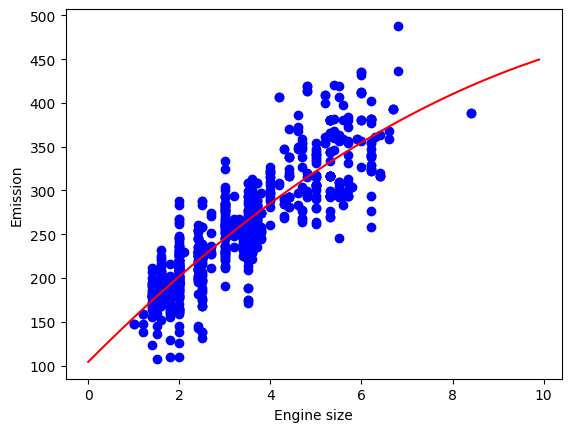

In [66]:
# plot the predected curve
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
XX = np.arange(0.0, 10.0, 0.1)
yy = clf.intercept_[0]+ clf.coef_[0][1]*XX+ clf.coef_[0][2]*np.power(XX, 2)
plt.plot(XX, yy, '-r' )
plt.xlabel("Engine size")
plt.ylabel("Emission")

In [67]:
# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(test_y, y_pred2)
mse = mean_squared_error(test_y, y_pred2)
r2 = r2_score(test_y, y_pred2)
# Print the error metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")

Mean Absolute Error (MAE): 21.09982618698728
Mean Squared Error (MSE): 724.7821844843612
R-squared (R²): 0.8039309020470193


## Practice

Try to use polynomial regression with the dataset, but this time with degree three (cubic). Does it result in better accuracy?

In [68]:
# Add your code here